In [1]:
print('test')

test


## 회귀

### 수업에 들어가기 전에(random seed 예제)

In [4]:
import random
import numpy as np

# Random seed 설정
random.seed(42)
np.random.seed(42)

# 난수 생성
random_number1 = random.random()   # 0이상 1미만의 난수를 생성 (1개 생성)
numpy_array1 = np.random.rand(3)   # 0과 1미만의 난수를 3개 생성 (여러개 생성)

print("첫 번째 실행:")
print("Python random:", random_number1)
print("NumPy array:", numpy_array1)

첫 번째 실행:
Python random: 0.6394267984578837
NumPy array: [0.37454012 0.95071431 0.73199394]


In [5]:
# 다시 실행 (random seed 설정 X)
random_number2 = random.random()
numpy_array2 = np.random.rand(3)

print("\n두 번째 실행 (seed 설정 X):")
print("Python random:", random_number2)
print("NumPy array:", numpy_array2)


두 번째 실행 (seed 설정 X):
Python random: 0.025010755222666936
NumPy array: [0.59865848 0.15601864 0.15599452]


In [6]:
# Random seed 설정 후 다시 실행
random.seed(42)
np.random.seed(42)

# 난수 생성
random_number3 = random.random()
numpy_array3 = np.random.rand(3)

print("\n세 번째 실행 (seed 설정):")
print("Python random:", random_number3)
print("NumPy array:", numpy_array3)


세 번째 실행 (seed 설정):
Python random: 0.6394267984578837
NumPy array: [0.37454012 0.95071431 0.73199394]


### 선형회귀

In [2]:
import os
print(os.getcwd())  # 현재 작업 디렉토리 확인
print(os.listdir())  # 현재 디렉토리의 파일 목록 확인

d:\pythonscript\study
['.venv', 'calculator.py', 'calculator_operations.py', 'hello_flask.py', 'ml.ipynb', 'pythonBasic01.ipynb', 'pythonFunction01.ipynb', 'pythonFunction02.ipynb', 'python_dbconn.py']


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import random

# 재현성(난수가 동일한 순서대로 출력)을 위해 random seed 설정
# random.seed(42)
# np.random.seed(42)

# 데이터 준비
X = np.array([[1],[2],[3],[4],[5]])         # 독립 변수
y = np.array([2, 4, 5, 4, 5])               # 종속 변수

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
predictions = model.predict(X_test)

# 결과 출력
print("학습 데이터 크기:", X_train.shape[0])
print("테스트 데이터 크기:", X_test.shape[0])
print("\n모델 계수:")
print("기울기 (slope):", model.coef_[0])

print("절편 (intercept):", model.intercept_)
print("\n테스트 세트 실제 값:", y_test)
print("테스트 세트 예측 값:", predictions)
print("\n모델 성능:")
print("R² 점수:", r2_score(y_test, predictions))
print("평균 제곱 오차 (MSE):", mean_squared_error(y_test, predictions))
print("평균 제곱근 오차 (RMSE):", root_mean_squared_error(y_test, predictions))

학습 데이터 크기: 3
테스트 데이터 크기: 2

모델 계수:
기울기 (slope): 0.7857142857142857
절편 (intercept): 1.5714285714285716

테스트 세트 실제 값: [4 5]
테스트 세트 예측 값: [3.14285714 5.5       ]

모델 성능:
R² 점수: -0.9693877551020396
평균 제곱 오차 (MSE): 0.4923469387755099
평균 제곱근 오차 (RMSE): 0.7016743822995891


### 다중선형회귀

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 샘플 데이터 생성
# 공부 시간(X1)과 과외 시간(X2)에 따른 시험 점수(Y) 예측
study_hours = np.array([2, 3, 4, 5, 4, 6, 7, 8, 5, 4])      # 하루 공부 시간
tutor_hours = np.array([0, 1, 0, 2, 1, 3, 2, 3, 2, 1])      # 주간 과외 시간
test_scores = np.array([60, 70, 75, 85, 75, 90, 92, 95, 80, 75])    # 시험 점수

# 입력 데이터 형태 맞추기
X = np.column_stack((study_hours, tutor_hours))
y = test_scores

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 결과 출력
print("회귀 계수:")
print(f"공부 시간: {model.coef_[0]: .2f}")
print(f"과외 시간: {model.coef_[1]: .2f}")
print(f"절편: {model.intercept_: .2f}")

회귀 계수:
공부 시간:  4.87
과외 시간:  1.94
절편:  53.39


In [11]:
# 새로운 데이터로 예측
new_student = np.array([[6, 2]])      # 공부 6시간, 과외 2시간
prediction = model.predict(new_student)
print(f"\n예측점수: {prediction[0]: .1f}")

# 모델 성능 평가(R-squared)
r_squared = model.score(X, y)
print(f"R-squared: {r_squared: .4f}")


예측점수:  86.5
R-squared:  0.9613


회귀 계수:
X1:  1.7882
X2:  2.9284
X3:  0.0135

절편:  4.6535

R-squared 값:  0.9497
평균제곱근오차(RMSE): 0.7174


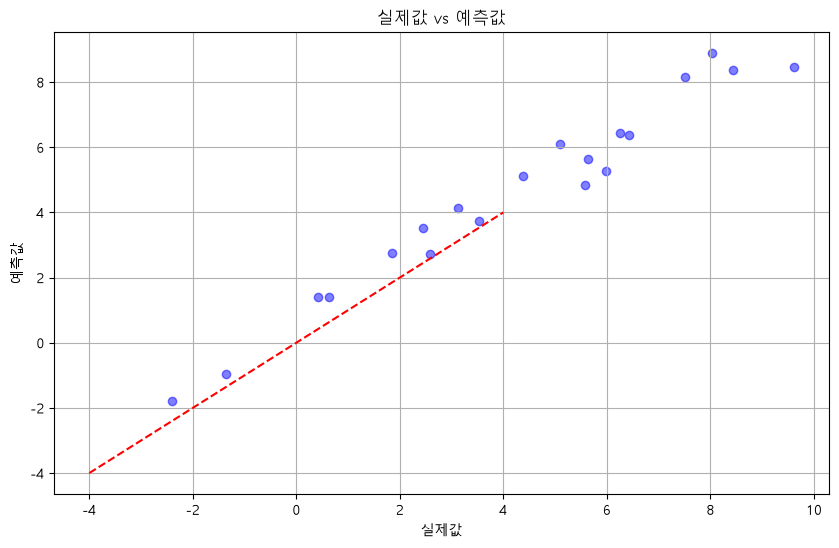


새로운 데이터 예측값: 8.4692


d:\pythonscript\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{: .2f}'.format

# 샘플 데이터 생성
np.random.seed(42)
n_samples = 100           # 생성할 난수 크기

# 독립변수 생성
#    np.random.normal(평균, 표준편차, 생성할 난수 크기)
X1 = np.random.normal(0, 1, n_samples)  
X2 = np.random.normal(0, 1, n_samples)
X3 = np.random.normal(0, 1, n_samples)

# 종속 변수 생성 (Y = 2X1, 3X2, 1.5X3 + 오차)
Y = 2 * X1 + 3 * X2 + 1.5 * 3 + np.random.normal(0, 1, n_samples)

# 데이터프레임 생성
data = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'Y': Y
})

# 학습용과 테스트용 데이터 분리
X = data[['X1', 'X2', 'X3']]
y = data['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 결과 출력
print("회귀 계수:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef: .4f}")
print(f"\n절편: {model.intercept_: .4f}")
print(f"\nR-squared 값: {r2_score(y_test, y_pred): .4f}")
print(f"평균제곱근오차(RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# 실제값과 예측값 비교 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5) # alpha(투명도) : 0(투명), 0.5(반투명), 1(완전 불투명)
plt.plot([-4, 4], [-4, 4], 'r--')  # X축 [-4, 4], Y축 [-4, 4]: 이 부분은 선의 시작점과 끝점을 정의 r-- : red색 -- 점선으로 표시
plt.xlabel('실제값')  # Actual value
plt.ylabel('예측값')  # Predicted value
plt.title('실제값 vs 예측값') # Actual value vs Predicted value
plt.grid(True)
plt.show()

# 새로운 데이터로 예측 예시
new_data = np.array([[0.5, 1.0, -0.5]])
prediction = model.predict(new_data)
print(f"\n새로운 데이터 예측값: {prediction[0]:.4f}")

#### 3D 시각화

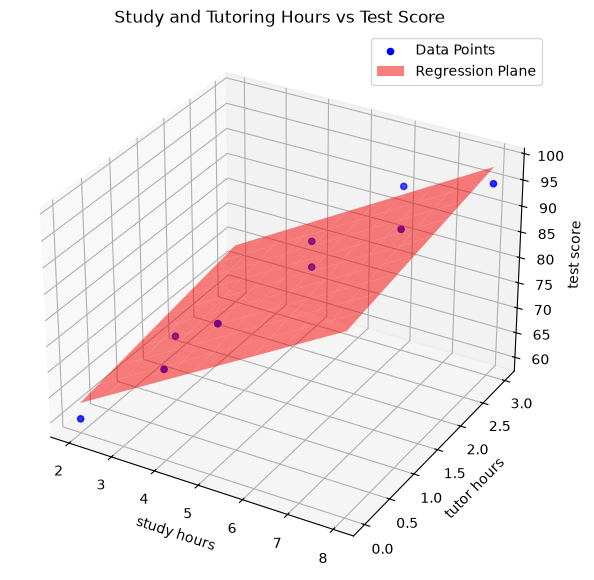

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D 시각화
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')      # 111 : 1행 1열 첫 번째 서브 플롯

# 데이터 점 산점도
ax.scatter(study_hours, tutor_hours, test_scores, color='blue', label='Data Points')

# 회귀 평면 생성
# X1, X2 범위의 격자 생성
# 회귀평면 최대값과 최소값 간격을 10개의 균일한 간격으로 나눔
x1_range = np.linspace(min(study_hours), max(study_hours), 10)  
x2_range = np.linspace(min(tutor_hours), max(tutor_hours), 10)

# x1_range와 x2_range를 결합하여 2D 격자(grid)를 생성
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# 회귀 평면의 Z값(예측 점수) 계산
y_grid = model.intercept_ + model.coef_[0] * x1_grid + model.coef_[1] * x2_grid

# 회귀 평면 그리기
ax.plot_surface(
    x1_grid, x2_grid, y_grid, color='red', alpha=0.5, label="Regression Plane")
    # alpha=0.5: 평면의 투명도

# 축 라벨 설정
ax.set_xlabel('study hours')
ax.set_ylabel('tutor hours')
ax.set_zlabel('test score')
ax.set_title('Study and Tutoring Hours vs Test Score')

# 범례 추가
ax.legend()

plt.show()

### 다항회귀

In [1]:
import os
print(os.getcwd())

d:\pythonscript\study


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
# 여러 단계를 순서대로 처리 및 연결(ex. 다항 특성 변환과 선형회귀 순서대로 적용)
from sklearn.pipeline import make_pipeline

# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{: .2f}'.format

# CSV 파일 읽기
dataset = pd.read_csv('../dataset/PolynomialRegressionData.csv')

In [ ]:
# 데이터 준비
X = dataset['hour'].values.reshape(-1, 1)   # 공부 시간(독립 변수), 2차원 배열
y = dataset['score'].values                 # 성적(종속 변수)

# 다항 회귀 모델 생성(2차 다항식)
degree = 2
polyreg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
polyreg.fit(X, y)

# 모델 성능 평가(R-sqaured)
r_squared = polyreg.score(X, y)
print(f"R-squared: {r_squared: .4f}")

# 새로운 데이터로 예측(공부 시간 3.8시간)
new_hours = np.array([[3.8]]) 
predicted_score = polyreg.predict(new_hours)
print(f"공부 시간 3.8시간에 대한 예측 성적: {predicted_score[0]: .1f}")

R-squared:  0.9755
공부 시간 3.8시간에 대한 예측 성적:  50.7


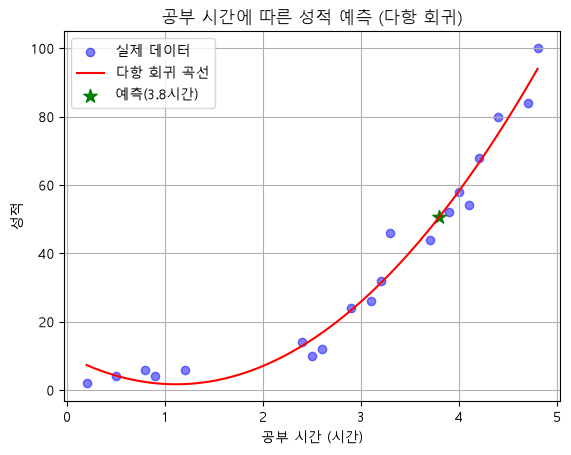

In [7]:
# 시각화
# 데이터 포인트 산점도
plt.scatter(X, y, color='blue', alpha=0.5, label='실제 데이터') # alpha : 투명도

# 다항 회귀 곡선 그리기
# 부드러운 곡선을 위해 범위 생성
# reshape(-1, 1) scikit-learn은 2차원 배열로 표현 (samples, features)
X_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_pred = polyreg.predict(X_range)
plt.plot(X_range, y_pred, color='red', label='다항 회귀 곡선')

# 예측 데이터 포인트 표시
plt.scatter(new_hours, predicted_score, color='green', 
            s=100, marker='*', label='예측(3.8시간)')

# 그래프 설정
plt.xlabel('공부 시간 (시간)')
plt.ylabel('성적')
plt.title('공부 시간에 따른 성적 예측 (다항 회귀)')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()

### Elastic Net 예제

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [11]:
# 데이터 로드
df = pd.read_csv('../dataset/LinearRegressionData.csv')

In [12]:
print(df.head())

   hour  score
0  0.50     10
1  1.20      8
2  1.80     14
3  2.40     26
4  2.60     22


In [13]:
# 독립변수(X), 종속변수(y)
X = df[['hour']]
y = df['score']

In [16]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42)

In [17]:
# 모델 생성
model = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [18]:
# 학습
model.fit(X_train, y_train)

# 예측
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [19]:
# 성능 평가
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n===== Train =====")
print("R² :", train_r2)
print("MSE :", train_mse)
print("RMSE :", train_rmse)
print("MAE :", train_mae)

print("\n===== Test =====")
print("R² :", test_r2)
print("MSE :", test_mse)
print("RMSE :", test_rmse)
print("MAE :", test_mae)


===== Train =====
R² : 0.9564496456420507
MSE : 25.214974698965825
RMSE : 5.021451453411237
MAE : 4.110255025751787

===== Test =====
R² : 0.932384654864545
MSE : 73.75143770649751
RMSE : 8.587865724759412
MAE : 7.102757933211502


In [20]:
# 회귀 계수 확인
print("절편(intercept):", model.intercept_)
print("가중치(coef):", model.coef_)

절편(intercept): -1.0679514869579663
가중치(coef): [10.78418342]


In [21]:
# 실제값 vs 예측값
result_df = pd.DataFrame({
    '실제점수': y_test.values,
    '예측점수': y_test_pred
})

print("실제값 vs 예측값")
print(result_df)

실제값 vs 예측값
   실제점수   예측점수
0    10   4.32
1    86  89.52
2    58  73.34
3     8  11.87


In [23]:
# 새로운 데이터 예측
new_hours = [[6]]
pred_score = model.predict(new_hours)

print(f"공부시간 6시간 예상 점수: {pred_score[0]: .2f}")

공부시간 6시간 예상 점수:  63.64


d:\pythonscript\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


d:\pythonscript\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


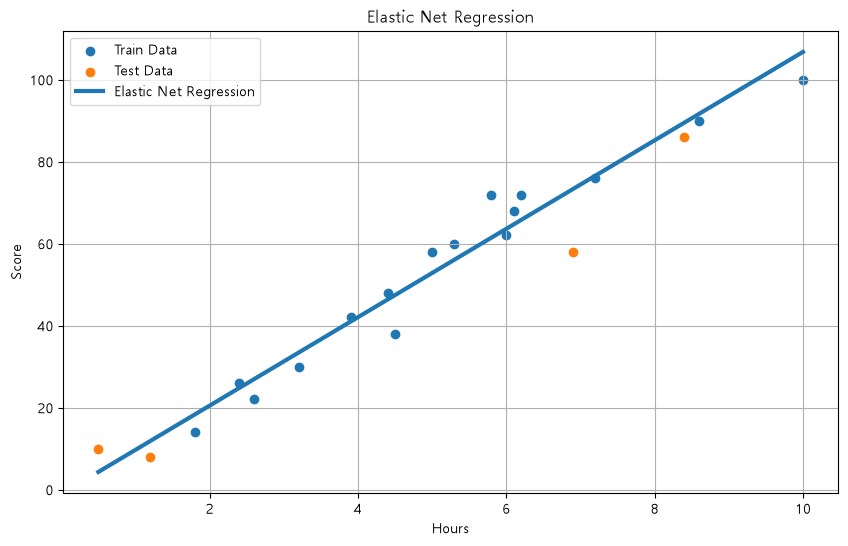

In [ ]:
# 시각화
plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, label='Train Data')
plt.scatter(X_test, y_test, label='Test Data')

X_sorted = np.sort(X.values, axis=0)
y_line = model.predict(X_sorted)

plt.plot(X_sorted, y_line, linewidth=3, label='Elastic Net Regression')

plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Elastic Net Regression")
plt.legend()
plt.grid(True)

plt.show()

## 분류

### 로지스틱 회귀 들어가기 전에(shape 변경 예제)

In [45]:
import numpy as np

# 2차원 배열 생성
p = np.array([[1, 2, 3], [4, 5, 6]])
print("Original array:\n", p)
print("Shape:", p.shape)

Original array:
 [[1 2 3]
 [4 5 6]]
Shape: (2, 3)


In [46]:
# reshape(-1) 적용
p = p.reshape(-1)
print("\nReshaped array:\n", p)
print("Shape:", p.shape)


Reshaped array:
 [1 2 3 4 5 6]
Shape: (6,)


In [47]:
# reshape(-1, 2) 적용
p = p.reshape(-1, 2)
print("\nReshaped array:\n", p)
print("Shape:", p.shape)


Reshaped array:
 [[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)


In [48]:
# reshape(3, -1) 적용
p = p.reshape(3, -1)
print("\nReshaped array:\n", p)
print("Shape:", p.shape)


Reshaped array:
 [[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)


### 로지스틱회귀 추가 학습 예제

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('../dataset/LogisticRegressionData.csv')
dataset.head()

,hour,pass
0,0.50,0
1,1.20,0
2,1.80,0
3,2.40,0
4,2.60,0


In [26]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [36]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

print(classifier.classes_)

[0 1]


In [37]:
classifier.predict([[6]])

array([1])

In [38]:
# predict_proba : 각 클래스에 속할 확률(분류에 사용)
classifier.predict_proba([[6]])

# print(classifier.classes_)를 찍어 본 이유 -> 순서와 매칭

array([[0.141483, 0.858517]])

In [39]:
classifier.predict([[4]])

array([0])

In [40]:
classifier.predict_proba([[4]])

array([[0.62497682, 0.37502318]])

In [41]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 1, 1])

In [42]:
y_test

array([1, 0, 1, 0])

In [43]:
X_test

array([[ 8.6],
       [ 1.2],
       [10. ],
       [ 4.5]])

In [44]:
# 정확도 반환
classifier.score(X_test, y_test)

0.75

### KNN(K Nearest Neighbors)

In [49]:
# 붓꽃(Iris) 품종 : Setosa, Versicolor, Viginica
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [51]:
# 1. 데이터 준비
iris = load_iris()
X = iris.data       # 특징 : 꽃잎/꽃받침 길이, 너비
y = iris.target     # 품종 : 0-Setosa, 1-Versicolor, 2-Virginica
feature_names = iris.feature_names      # 특징 이름 가져오기
target_names = iris.target_names        # 타겟 이름 가져오기

In [ ]:
# Pandas DataFrame 생성 및 출력
# feature_names 리스트의 값을 순서대로 매핑하여 열 이름을 설정
df = pd.DataFrame(X, columns=feature_names)  
df['target'] = y    # 품종 레이블 추가
df['target_name'] = df['target'].apply(lambda x: target_names[x])   # 품종 이름 추가

print("Iris Data (Head 5):")
print(df.head())

Iris Data (Head 5):
   sepal length (cm)  sepal width (cm)  ...  target  target_name
0               5.10              3.50  ...       0       setosa
1               4.90              3.00  ...       0       setosa
2               4.70              3.20  ...       0       setosa
3               4.60              3.10  ...       0       setosa
4               5.00              3.60  ...       0       setosa

[5 rows x 6 columns]


In [ ]:
# 2. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [56]:
# 3. KNN 모델 생성 및 학습
k = 5       # K 값 생성(이웃의 수)
knn = KNeighborsClassifier(n_neighbors=k)   # 모델 생성
knn.fit(X_train, y_train);   # 훈련 데이터로 모델 학습

In [57]:
# 4. 테스트 데이터로 예측
y_pred = knn.predict(X_test)

In [61]:
# 5. 모델 평가
accuracy = accuracy_score(y_test, y_pred) # 정확도 계산
print(f"Accuracy: {accuracy:.4f}") # 결과 출력

Accuracy: 1.0000


In [62]:
# 6. 새로운 데이터에 대한 예측 (선택 사항)
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # 새로운 데이터 (꽃잎, 꽃받침 길이/너비)
prediction = knn.predict(new_data)
print(f"New data prediction: {iris.target_names[prediction[0]]}") # 예측 결과 출력

New data prediction: setosa


### 의사결정나무

In [63]:
# 붓꽃(Iris) 품종 : Setosa, Versicolor, Viginica
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree      # 의사결정나무의 구조를 그래픽으로 표현

In [64]:
# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [65]:
# Pandas DataFrame 생성
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_names'] = [target_names[i] for i in y]       # 타겟 이름 추가

In [66]:
# 데이터프레임 출력(처음 5행)
print("DataFrame Sample")
print(df.head())

DataFrame Sample
   sepal length (cm)  sepal width (cm)  ...  target  target_names
0               5.10              3.50  ...       0        setosa
1               4.90              3.00  ...       0        setosa
2               4.70              3.20  ...       0        setosa
3               4.60              3.10  ...       0        setosa
4               5.00              3.60  ...       0        setosa

[5 rows x 6 columns]


In [67]:
# 데이터 분할(훈련 세트 80%, 테스트 세트 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [68]:
# 의사결정 트리 모델 생성(모델 파라미녀 튜닝 가능)
# max_depth(나무의 최대 깊이) 조절
clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# 모델 학습
clf.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = clf.predict(X_test)

In [69]:
# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [70]:
# 분류 보고서
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



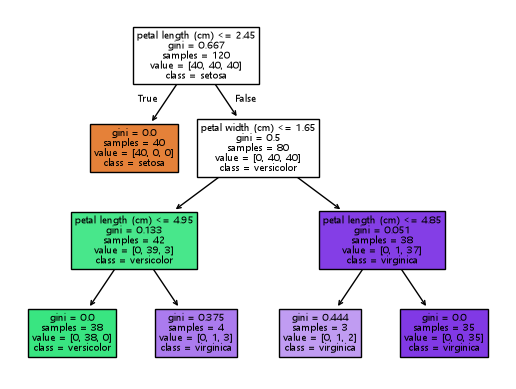

In [72]:
# 의사결정트리 시각화
plt.Figure(figsize=(12, 8))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.show()

### 랜덤포레스트

In [81]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns       # Confusion matrix 시각화를 위해 추가

In [83]:
# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [84]:
# Pandas DataFrame 생성
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_name'] = [target_names[i] for i in y]    # target 이름 추가

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.10,3.50,1.40,0.20,0,setosa
1,4.90,3.00,1.40,0.20,0,setosa
2,4.70,3.20,1.30,0.20,0,setosa
3,4.60,3.10,1.50,0.20,0,setosa
4,5.00,3.60,1.40,0.20,0,setosa


In [85]:
# 데이터 분할
# stratify=y: 데이터 분할 시 클래스 불균형 해결
#             (클래스 비율 유지하면서 훈련, 테스트 데이터셋 분리)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [91]:
# Random Forest 모델 생성
# 하이퍼파라미터 튜닝을 위해 GridSearchCV 사용
param_grid = {
    'n_estimators': [50, 100, 200],   # 트리의 개수
    'max_depth': [4, 6, 8],          # 트리의 최대 깊이
    'min_samples_split': [2, 4],     # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2]       # 리프 노드에 있어야 하는 최소 샘플 수   
}

In [ ]:
rf_model = RandomForestClassifier(random_state=42)      # Random Forest 모델 초기화
# 교차 검증 cv=3 : 훈련 데이터를 3개의 FOLD(묶음)으로 나누어서 
#                 두 개를 훈련, 나머지는 검증 용도로 활용
# 교차 검증은 최적의 하이퍼 파라미터 값을 찾기 위해서 사용됨
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy')

In [93]:
# 모델 학습(GridSearchCV를 통한 최적의 파라미터를 반영한 학습)
grid_search.fit(X_train, y_train)

# 최적의 파라미터 출력
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [94]:
# 최적의 모델 저장
best_rf_model = grid_search.best_estimator_

In [95]:
# 테스트 데이터로 예측(하이퍼 파라미터 튜닝을 통해 최적화된 상태로 예측이 이루어짐)
y_pred = best_rf_model.predict(X_test)

In [97]:
# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [98]:
# 분류 보고서
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



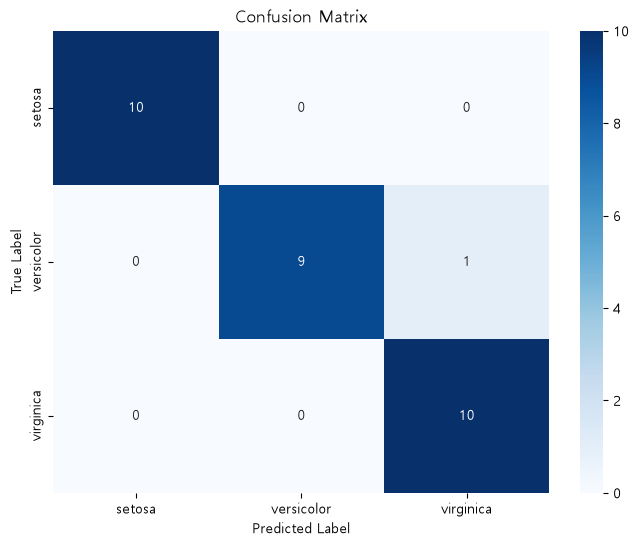

In [100]:
# 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

# annot=True : 각 셀안의 숫자값을 표시 
# fmt="d" : 숫자값을 정수형태로 표시 
# cmap="Blues" : 색상값은 블루
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

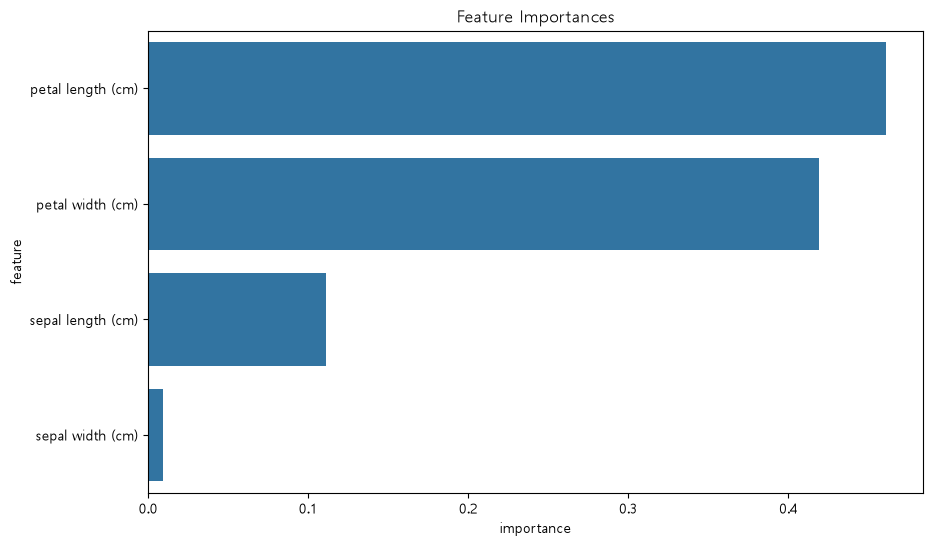

In [101]:
# Feature Importance 시각화
feature_importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(
    'importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.show()

### 나이브 베이즈(Naive Bayes) : 텍스트 분류 문제에서 매우 효과적

In [102]:
# 스팸 분류 예제
import pandas as pd
from sklearn.model_selection import train_test_split
# 텍스트 데이터를 숫자로 변환 (TF-IDF 벡터화)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [109]:
# 1. 데이터 불러오기
# encoding 방식 : utf-8(범용성), ISO-8859-1(서유럽), CP949(한글)
data = pd.read_csv('../dataset/spam.csv', encoding='ISO-8859-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [110]:
data = data[['v1', 'v2']]           # 필요한 열만 선택
data.columns = ['label', 'text']    # 열 이름 변경

In [111]:
data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [112]:
# 2. 데이터 전처리
# 레이블을 숫자로 변환, map함수: 열의 각 값을 다른 값으로 변환하는 데 사용
data['label'] = data['label'].map({'ham':0, 'spam':1})
data.dropna(inplace=True)       # 결측치 제거

In [113]:
# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)

In [114]:
# 4. TF-IDF 벡터화
# stop_words: 불필요한 영어 단어(예: "the", "is", "and" 등)를 자동으로 제거
vectorizer = TfidfVectorizer(stop_words='english')
# fit: 학습 데이터의 중요한 통계정보(단어빈도수)학습, transform: 숫자 벡터로 변환
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [116]:
# 5. 모델 학습
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

Accuracy: 0.9668161434977578
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [118]:
# 7. 샘플 테스트
sample_text = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
               "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
               "Hey, are we meeting for lunch tomorrow?"]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text: {text} => {'Spam' if label == 1 else 'Ham'}")

Text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text: Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text: Hey, are we meeting for lunch tomorrow? => Ham


### SVM(support vector machine)

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [120]:
# 1. 데이터 불러오기
data = pd.read_csv('../dataset/spam.csv', encoding='ISO-8859-1')
data = data[['v1', 'v2']]  
data.columns = ['label', 'text']  

In [121]:
# 2. 데이터 전처리
data['label'] = data['label'].map({'ham': 0, 'spam': 1})    # 레이블을 숫자로 변환
data.dropna(inplace=True)       # 결측치 제거

In [122]:
# 3.학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)

In [123]:
# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [124]:
# 5. SVM 모델 학습
# SVM 모델 생성 (linear : 직선, 평면, 초평면)
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_tfidf, y_train)

# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.979372197309417

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [125]:
# 7. 샘플 테스트
sample_text = [
    "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
    "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
    "Hey, are we meeting for lunch tomorrow?"
]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text: {text} => {'Spam' if label == 1 else 'Ham'}")

Text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text: Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text: Hey, are we meeting for lunch tomorrow? => Ham
